# Оценка экономической эффективности внедрения облачной CRM

## Цель работы

Оценить экономическую эффективность внедрения облачной CRM-системы для отдела продаж компании «ТехноПром».

В рамках работы рассчитываются:

* прямой экономический эффект от внедрения CRM;
* затраты на внедрение и использование системы;
* прирост чистой прибыли;
* чистая приведённая стоимость проекта (NPV);
* простой срок окупаемости;
* рентабельность инвестиций (ROI);
* нематериальные эффекты от внедрения CRM.

**Горизонт оценки проекта:** 3 года.


## 1. Исходные данные

Для расчёта используются данные из условия задачи.

| Показатель                                 |          Значение | Обозначение |
| ------------------------------------------ | ----------------: | ----------- |
| Количество менеджеров                      |           15 чел. | \(N\)       |
| Средняя зарплата менеджера                 | 120 000 руб./мес. | \(Z\)       |
| Доля рабочего времени на рутинные операции |               30% | \(D_r\)     |
| Экономия времени после внедрения CRM       |               20% | \(E_t\)     |
| Рост продаж после внедрения CRM            |          8% в год | \(G\)       |
| Текущий годовой оборот                     |   72 000 000 руб. | \(V\)       |
| Стоимость CRM на пользователя              |   24 000 руб./год | \(C_u\)     |
| Период обучения                            |           1 месяц | \(T\)       |
| Горизонт оценки                            |            3 года | \(n\)       |
| Ставка дисконтирования                     |               12% | \(r\)       |
| Налог на прибыль                           |               20% | \(t\)       |

### Обозначения

* \(N\) — количество менеджеров;
* \(Z\) — средняя месячная зарплата одного менеджера;
* \(D_r\) — доля рабочего времени, приходящаяся на рутинные операции;
* \(E_t\) — доля времени на рутинные операции, которую позволяет сэкономить CRM;
* \(G\) — ожидаемый темп роста продаж;
* \(V\) — текущий годовой оборот;
* \(C_u\) — стоимость CRM для одного пользователя за год;
* \(T\) — продолжительность периода обучения;
* \(n\) — количество лет оценки проекта;
* \(r\) — ставка дисконтирования;
* \(t\) — ставка налога на прибыль.


## 2. Допущения модели

В исходных данных отсутствует информация о переменных затратах компании, связанных с производством и реализацией дополнительного объёма продукции или услуг.

Поэтому принимается следующее допущение:

> **Переменные затраты на дополнительный объём продаж принимаются близкими к нулю.**

При таком допущении дополнительная выручка от роста продаж может рассматриваться как дополнительный финансовый эффект до налогообложения.

### Дополнительное допущение по обучению

В условии указано, что период обучения и адаптации составляет 1 месяц. Для оценки потерь принимается, что в течение этого месяца компания несёт потери производительности, эквивалентные месячному фонду оплаты труда менеджеров.

### Важное ограничение

Полученные результаты являются **оценочными**, поскольку фактический экономический эффект CRM зависит от реальной структуры затрат, степени использования системы сотрудниками и фактического изменения продаж.


In [1]:
# Импортируем библиотеки, которые понадобятся для расчётов
import pandas as pd

In [2]:
# =========================
# ИСХОДНЫЕ ДАННЫЕ
# =========================

# Количество менеджеров в отделе продаж, чел.
managers = 15

# Средняя месячная зарплата одного менеджера, руб.
salary = 120_000

# Доля рабочего времени, которую менеджеры тратят
# на рутинные операции без CRM
routine_share = 0.30

# Доля времени на рутинные операции,
# которую позволяет сэкономить CRM
time_saving = 0.20

# Ожидаемый рост продаж после внедрения CRM
sales_growth = 0.08

# Текущий годовой оборот отдела продаж, руб.
annual_turnover = 72_000_000

# Стоимость CRM для одного пользователя за год, руб.
crm_cost_user = 24_000

# Продолжительность обучения и адаптации, месяцев
training_months = 1

# Горизонт оценки проекта, лет
years = 3

# Ставка дисконтирования
discount_rate = 0.12

# Налог на прибыль
tax_rate = 0.20

print("Исходные данные загружены.")

Исходные данные загружены.


## 3. Расчёт годового фонда оплаты труда

Сначала определим, сколько компания тратит на заработную плату всех менеджеров за год.

### Формула

$$
ФОТ_{год} = N \times Z \times 12
$$

где:

* \(ФОТ_{год}\) — годовой фонд оплаты труда менеджеров;
* \(N\) — количество менеджеров;
* \(Z\) — средняя месячная зарплата одного менеджера;
* \(12\) — количество месяцев в году.

### Подстановка

$$
ФОТ_{год} =
15 \times 120\,000 \times 12
=
21\,600\,000\text{ руб.}
$$

Таким образом, годовой фонд оплаты труда отдела продаж составляет **21,6 млн руб.**


In [3]:
# Рассчитываем годовой фонд оплаты труда.
# Формула:
# количество менеджеров × месячная зарплата × 12 месяцев

annual_salary_fund = managers * salary * 12

print(f"Годовой фонд оплаты труда: {annual_salary_fund:,.0f} руб.")

Годовой фонд оплаты труда: 21,600,000 руб.


## 4. Стоимость времени, затрачиваемого на рутинные операции

По условию менеджеры тратят на рутинные операции **30% рабочего времени**.

Чтобы определить стоимость этого времени для компании, умножаем годовой фонд оплаты труда на долю рабочего времени, приходящуюся на рутинные операции.

### Формула

$$
З_{рутин} = ФОТ_{год} \times D_r
$$

где:

* \(З_{рутин}\) — стоимость рабочего времени, затрачиваемого на рутинные операции;
* \(ФОТ_{год}\) — годовой фонд оплаты труда;
* \(D_r\) — доля рабочего времени на рутинные операции.

### Расчёт

$$
З_{рутин}
=
21\,600\,000 \times 0{,}30
=
6\,480\,000\text{ руб.}
$$

Следовательно, стоимость рабочего времени менеджеров, приходящегося на рутинные операции, составляет **6,48 млн руб. в год**.


In [4]:
# Рассчитываем стоимость рабочего времени,
# которое менеджеры тратят на рутинные операции.

routine_cost = annual_salary_fund * routine_share

print(f"Стоимость рутинных операций: {routine_cost:,.0f} руб./год")

Стоимость рутинных операций: 6,480,000 руб./год


## 5. Экономия на заработной плате за счёт CRM

CRM позволяет сократить время, которое менеджеры тратят на рутинные операции, на **20%**.

Поэтому экономический эффект рассчитывается как 20% от стоимости времени, затрачиваемого на рутинные операции.

### Формула

$$
Э_{зарп} = З_{рутин} \times E_t
$$

где:

* $Э_{зарп}$ — годовая экономия на заработной плате;
* $З_{рутин}$ — стоимость времени на рутинные операции;
* $E_t$ — доля времени, которую позволяет сэкономить CRM.

### Расчёт

$$
Э_{зарп}
=
6\,480\,000 \times 0{,}20
=
1\,296\,000\text{ руб.}
$$

Таким образом, расчётная экономия составляет **1,296 млн руб. в год**.


In [5]:
# Рассчитываем годовую экономию на заработной плате.
# CRM экономит 20% времени, которое раньше тратилось
# на рутинные операции.

salary_saving = routine_cost * time_saving

print(f"Экономия на заработной плате: {salary_saving:,.0f} руб./год")

Экономия на заработной плате: 1,296,000 руб./год


### Дополнительная выручка от роста продаж

Ожидаемый рост продаж после внедрения CRM составляет 8% в год. Текущая годовая выручка отдела продаж — 72 млн руб.

Дополнительная выручка определяется по формуле:

$$
\Delta V = V \times g
$$

где:

* $\Delta V$ — дополнительная выручка от роста продаж, руб.;
* $V$ — текущая годовая выручка, руб.;
* $g$ — темп роста продаж.

Подставим исходные данные:

$$
\Delta V = 72\,000\,000 \times 0{,}08 =
5\,760\,000 \text{ руб.}
$$

Таким образом, благодаря ожидаемому росту продаж на 8% компания получает дополнительную выручку **5,76 млн руб. в год**.

В дальнейшем, поскольку переменные затраты принимаются близкими к нулю, данная величина будет рассматриваться как дополнительный финансовый эффект до налогообложения.


In [6]:
# Расчёт дополнительной выручки от роста продаж
additional_revenue = annual_turnover * sales_growth

# Вывод результата
print(f"Дополнительная выручка: {additional_revenue:,.0f} руб.")

Дополнительная выручка: 5,760,000 руб.


### Общий экономический эффект

Общий экономический эффект от внедрения CRM складывается из экономии на заработной плате и дополнительной выручки от роста продаж:

$$
Э_{общ} = Э_{зарп} + \Delta V
$$

где:

* $Э_{общ}$ — общий годовой эффект до учёта затрат и налога, руб.;
* $Э_{зарп}$ — экономия на заработной плате, руб.;
* $\Delta V$ — дополнительная выручка от роста продаж, руб.

Подставим рассчитанные значения:

$$
Э_{общ} =
1\,296\,000 + 5\,760\,000 =
7\,056\,000 \text{ руб.}
$$

Таким образом, общий ожидаемый эффект от внедрения CRM составляет **7,056 млн руб. в год до учёта затрат и налога**.


In [7]:
# Общий годовой эффект от внедрения CRM
total_effect = salary_saving + additional_revenue

print(f"Общий годовой эффект: {total_effect:,.0f} руб.")

Общий годовой эффект: 7,056,000 руб.


### Затраты на лицензии CRM

Годовая стоимость использования CRM определяется как произведение количества пользователей на стоимость лицензии одного пользователя:

$$
C_{CRM} = N \times C_{user}
$$

где:

* $C_{CRM}$ — годовые затраты на CRM, руб.;
* $N$ — количество пользователей;
* $C_{user}$ — стоимость CRM на одного пользователя в год, руб.

Подставим данные:

$$
C_{CRM} =
15 \times 24\,000 =
360\,000 \text{ руб.}
$$

Таким образом, годовые затраты на использование CRM составляют **360 тыс. руб.**

За три года:

$$
C_{CRM,3} = 360\,000 \times 3 =
1\,080\,000 \text{ руб.}
$$

Следовательно, общая стоимость лицензий за расчётный период составляет **1,08 млн руб.**


In [8]:
# Годовые затраты на лицензии CRM
crm_cost_year = managers * crm_cost_user

# Затраты на CRM за весь период оценки
crm_cost_total = crm_cost_year * years

print(f"Годовые затраты на CRM: {crm_cost_year:,.0f} руб.")
print(f"Затраты на CRM за {years} года: {crm_cost_total:,.0f} руб.")

Годовые затраты на CRM: 360,000 руб.
Затраты на CRM за 3 года: 1,080,000 руб.


### Потери производительности в период обучения

В первый месяц после внедрения CRM сотрудники проходят обучение и адаптацию. В этот период возникает потеря производительности.

В рамках расчётной модели принимаем, что потери производительности за один месяц соответствуют месячному фонду заработной платы отдела:

$$
C_{train} = N \times Z \times M
$$

где:

* $C_{train}$ — потери от снижения производительности, руб.;
* $N$ — количество менеджеров;
* $Z$ — среднемесячная заработная плата одного менеджера, руб.;
* $M$ — продолжительность периода адаптации, мес.

Подставим значения:

$$
C_{train} =
15 \times 120\,000 \times 1 =
1\,800\,000 \text{ руб.}
$$

Таким образом, в модели учитываются потери производительности в размере **1,8 млн руб.** в первый год.

Это является расчётным допущением, поскольку в условии не указано, какую именно долю производительности сотрудники теряют в период обучения.


In [9]:
# Потери производительности в период обучения
training_loss = managers * salary * training_months

print(f"Потери производительности: {training_loss:,.0f} руб.")

Потери производительности: 1,800,000 руб.


### Чистый финансовый эффект по годам

Для оценки экономической эффективности необходимо определить финансовый эффект от внедрения CRM по каждому году расчётного периода.

Сначала определяется прибыль до налогообложения:

$$
P_t = Э_{общ} - C_{CRM} - C_{train,t}
$$

где:

* $P_t$ — прибыль от внедрения CRM до налогообложения в году $t$;
* $Э_{общ}$ — общий годовой экономический эффект;
* $C_{CRM}$ — годовые затраты на CRM;
* $C_{train,t}$ — потери производительности в году $t$.

В первом году учитываются затраты на обучение и адаптацию сотрудников:

$$
P_1 =
7\,056\,000 - 360\,000 - 1\,800\,000
= 4\,896\,000 \text{ руб.}
$$

Во втором и третьем годах потери производительности отсутствуют:

$$
P_2=P_3=
7\,056\,000-360\,000
=6\,696\,000 \text{ руб.}
$$

Далее рассчитывается налог на прибыль:

$$
Tax_t=P_t\times T
$$

где $T=20%$ — ставка налога на прибыль.

Для первого года:

$$
Tax_1=4\,896\,000\times0{,}20
=979\,200 \text{ руб.}
$$

Для второго и третьего годов:

$$
Tax_2=Tax_3=
6\,696\,000\times0{,}20
=1\,339\,200 \text{ руб.}
$$

Чистый финансовый эффект определяется как прибыль после уплаты налога:

$$
CF_t=P_t-Tax_t
$$

Таким образом:

$$
CF_1=4\,896\,000-979\,200
=3\,916\,800 \text{ руб.}
$$

$$
CF_2=CF_3=
6\,696\,000-1\,339\,200
=5\,356\,800 \text{ руб.}
$$

Получаем следующие денежные потоки:

| Год | Прибыль до налога | Налог 20% | Чистый эффект |
| --- | ----------------: | --------: | ------------: |
| 1   |         4 896 000 |   979 200 | **3 916 800** |
| 2   |         6 696 000 | 1 339 200 | **5 356 800** |
| 3   |         6 696 000 | 1 339 200 | **5 356 800** |

Таким образом, в первый год чистый эффект ниже из-за потерь производительности в период обучения и адаптации. Со второго года чистый годовой эффект увеличивается до **5,357 млн руб.**


In [10]:
# Создаём список лет
project_years = [1, 2, 3]

# Потери производительности по годам:
# в первый год есть обучение, в последующие годы его уже нет
training_losses = [training_loss, 0, 0]

# Создаём пустые списки для результатов
profit_before_tax = []
taxes = []
net_cash_flows = []

# Рассчитываем показатели для каждого года
for year, training_loss_year in zip(project_years, training_losses):
    
    # Прибыль до налога
    profit = total_effect - crm_cost_year - training_loss_year
    
    # Налог на прибыль
    tax = profit * tax_rate
    
    # Чистый финансовый эффект
    net_effect = profit - tax
    
    # Сохраняем результаты
    profit_before_tax.append(profit)
    taxes.append(tax)
    net_cash_flows.append(net_effect)

# Вывод результатов
for i in range(years):
    print(f"Год {project_years[i]}:")
    print(f"  Прибыль до налога: {profit_before_tax[i]:,.0f} руб.")
    print(f"  Налог: {taxes[i]:,.0f} руб.")
    print(f"  Чистый эффект: {net_cash_flows[i]:,.0f} руб.")
    print()

Год 1:
  Прибыль до налога: 4,896,000 руб.
  Налог: 979,200 руб.
  Чистый эффект: 3,916,800 руб.

Год 2:
  Прибыль до налога: 6,696,000 руб.
  Налог: 1,339,200 руб.
  Чистый эффект: 5,356,800 руб.

Год 3:
  Прибыль до налога: 6,696,000 руб.
  Налог: 1,339,200 руб.
  Чистый эффект: 5,356,800 руб.



### Расчёт чистой приведённой стоимости проекта

Для оценки эффективности проекта с учётом фактора времени используется показатель чистой приведённой стоимости (NPV — Net Present Value).

NPV показывает текущую стоимость будущих денежных потоков проекта с учётом ставки дисконтирования.

Формула:

$$
NPV=\sum_{t=1}^{n}\frac{CF_t}{(1+r)^t}
$$

где:

* $NPV$ — чистая приведённая стоимость проекта;
* $CF_t$ — денежный поток в году $t$;
* $r$ — ставка дисконтирования;
* $t$ — номер года;
* $n$ — расчётный горизонт проекта.

В расчёте используется ставка дисконтирования **12%**, а денежные потоки составляют:

* 1-й год — 3 916 800 руб.;
* 2-й год — 5 356 800 руб.;
* 3-й год — 5 356 800 руб.

Тогда:

$$
NPV=
\frac{3\,916\,800}{1{,}12}
+
\frac{5\,356\,800}{1{,}12^2}
+
\frac{5\,356\,800}{1{,}12^3}
$$

$$
NPV \approx 11\,575\,826 \text{ руб.}
$$

Таким образом, **NPV проекта составляет примерно 11,58 млн руб.**

Поскольку NPV имеет положительное значение, внедрение CRM в рамках принятой модели является экономически целесообразным: приведённые денежные эффекты превышают приведённые затраты проекта.


In [11]:
# Расчёт NPV
npv = 0

for year, cash_flow in zip(project_years, net_cash_flows):
    # Приводим денежный поток будущего года к текущей стоимости
    present_value = cash_flow / (1 + discount_rate) ** year
    
    # Добавляем приведённый денежный поток к NPV
    npv += present_value

print(f"NPV проекта: {npv:,.0f} руб.")

NPV проекта: 11,580,415 руб.


### Расчёт срока окупаемости

Срок окупаемости показывает, за какой период первоначальные затраты на внедрение CRM компенсируются получаемым экономическим эффектом.

В качестве первоначальных затрат учитываются расходы на обучение и адаптацию сотрудников и стоимость CRM за первый год:

$$
C_{initial}=C_{train}+C_{CRM}
$$

$$
C_{initial}=1\,800\,000+360\,000
=2\,160\,000 \text{ руб.}
$$

После завершения периода обучения годовой чистый эффект составляет:

$$
CF_{year}=5\,356\,800 \text{ руб.}
$$

Упрощённый срок окупаемости определяется по формуле:

$$
PP=\frac{C_{initial}}{CF_{year}}
$$

Подставим значения:

$$
PP=
\frac{2\,160\,000}{5\,356\,800}
\approx0{,}403\text{ года}
$$

В месяцах:

$$
PP=0{,}403\times12\approx4{,}8\text{ месяца}
$$

Таким образом, при принятых допущениях проект окупается примерно за **4,8 месяца**.

Полученный результат означает, что относительно небольшие затраты на внедрение CRM компенсируются достаточно быстро за счёт роста продаж и сокращения затрат на рутинные операции.


In [12]:
# Первоначальные затраты:
# обучение + CRM за первый год
initial_costs = training_loss + crm_cost_year

# Годовой чистый эффект после первого года
# (когда расходы на обучение уже отсутствуют)
annual_net_effect = net_cash_flows[1]

# Срок окупаемости в годах
payback_years = initial_costs / annual_net_effect

# Переводим срок окупаемости в месяцы
payback_months = payback_years * 12

print(f"Первоначальные затраты: {initial_costs:,.0f} руб.")
print(f"Срок окупаемости: {payback_months:.1f} месяцев")

Первоначальные затраты: 2,160,000 руб.
Срок окупаемости: 4.8 месяцев


### Расчёт рентабельности инвестиций

Для оценки отдачи от затрат на внедрение CRM используется показатель ROI (Return on Investment).

В расчёте учитываются все затраты проекта за трёхлетний период:

$$
C_{total}=C_{CRM,3}+C_{train}
$$

где:

* $C_{total}$ — общие затраты проекта;
* $C_{CRM,3}$ — затраты на CRM за три года;
* $C_{train}$ — потери производительности в период обучения.

Подставим значения:

$$
C_{total}=1\,080\,000+1\,800\,000
=2\,880\,000 \text{ руб.}
$$

Суммарный чистый финансовый эффект за три года:

$$
CF_{total}=CF_1+CF_2+CF_3
$$

$$
CF_{total}=
3\,916\,800+5\,356\,800+5\,356\,800
=14\,630\,400 \text{ руб.}
$$

ROI определяется по формуле:

$$
ROI=\frac{CF_{total}}{C_{total}}\times100\%
$$

Подставим значения:

$$
ROI=
\frac{14\,630\,400}{2\,880\,000}\times100\%
\approx507{,}3\%
$$

Таким образом, ROI проекта составляет примерно **507,3%**.

Это означает, что за трёхлетний период на каждый рубль затрат приходится около **5,07 руб. чистого финансового эффекта**.

Полученный показатель свидетельствует о высокой экономической эффективности внедрения CRM в рамках заданных исходных данных и принятых допущений.


In [13]:
# Общие затраты за весь период:
# CRM за 3 года + обучение и адаптация
total_costs = crm_cost_total + training_loss

# Суммарный чистый финансовый эффект за 3 года
total_net_cash_flow = sum(net_cash_flows)

# Расчёт ROI
roi = (total_net_cash_flow / total_costs) * 100

print(f"Общие затраты: {total_costs:,.0f} руб.")
print(f"Суммарный чистый эффект: {total_net_cash_flow:,.0f} руб.")
print(f"ROI: {roi:.1f}%")

Общие затраты: 2,880,000 руб.
Суммарный чистый эффект: 14,630,400 руб.
ROI: 508.0%


### Нематериальные эффекты от внедрения CRM

Помимо рассчитанного финансового эффекта, внедрение CRM может дать компании ряд нематериальных преимуществ:

1. **Повышение качества управления продажами.**
   Руководитель получает более полную и структурированную информацию о работе менеджеров, клиентах и текущих сделках.

2. **Централизация информации о клиентах.**
   Данные о клиентах, контактах, обращениях и сделках хранятся в единой системе, что снижает зависимость от отдельных сотрудников.

3. **Повышение прозрачности работы отдела продаж.**
   Руководитель может контролировать состояние сделок и выполнение поставленных задач.

4. **Снижение риска потери информации.**
   История взаимодействия с клиентом сохраняется в системе и может использоваться другими сотрудниками.

5. **Улучшение клиентского сервиса.**
   Наличие полной истории взаимодействия позволяет быстрее обрабатывать обращения и лучше учитывать потребности клиентов.

6. **Стандартизация бизнес-процессов.**
   CRM позволяет формализовать отдельные этапы работы с клиентами и снизить зависимость результатов от индивидуального подхода отдельных менеджеров.

Таким образом, часть положительных результатов внедрения CRM сложно непосредственно выразить в денежных единицах, однако они могут способствовать повышению устойчивости и управляемости отдела продаж в долгосрочной перспективе.


### Влияние парадокса Солоу

При оценке эффективности внедрения CRM необходимо учитывать так называемый парадокс Солоу: инвестиции в информационные технологии сами по себе не гарантируют автоматического роста производительности.

Получение рассчитанного экономического эффекта зависит не только от приобретения CRM, но и от того, насколько эффективно сотрудники и руководство используют её возможности.

Например, если сотрудники продолжают выполнять операции по старым схемам, недостаточно используют функциональность CRM или не поддерживают данные в актуальном состоянии, фактический эффект может оказаться ниже расчётного.

Поэтому рассчитанные показатели экономической эффективности следует рассматривать как **прогноз при выполнении заданных условий**, а не как гарантированный финансовый результат.

Для снижения влияния парадокса Солоу компании необходимо обеспечить обучение сотрудников, адаптацию бизнес-процессов к новой системе и контроль использования CRM.

Таким образом, внедрение технологии должно сопровождаться организационными изменениями. Только в этом случае инвестиции в CRM смогут трансформироваться в реальное повышение производительности и финансовый результат.


In [14]:
# Формируем итоговую таблицу экономической эффективности

summary = pd.DataFrame({
    "Показатель": [
        "Экономия на заработной плате, руб./год",
        "Дополнительная выручка, руб./год",
        "Общий эффект, руб./год",
        "CRM, руб./год",
        "CRM за 3 года, руб.",
        "Потери производительности, руб.",
        "NPV, руб.",
        "Срок окупаемости, месяцев",
        "ROI, %"
    ],
    "Значение": [
        salary_saving,
        additional_revenue,
        total_effect,
        crm_cost_year,
        crm_cost_total,
        training_loss,
        npv,
        payback_months,
        roi
    ]
})

summary

,Показатель,Значение
0,"Экономия на заработной плате, руб./год",1.296000e+06
1,"Дополнительная выручка, руб./год",5.760000e+06
2,"Общий эффект, руб./год",7.056000e+06
3,"CRM, руб./год",3.600000e+05
4,"CRM за 3 года, руб.",1.080000e+06
5,"Потери производительности, руб.",1.800000e+06
6,"NPV, руб.",1.158042e+07
7,"Срок окупаемости, месяцев",4.838710e+00
8,"ROI, %",5.080000e+02


## Итоговый вывод

По результатам проведённой оценки внедрение облачной CRM для отдела продаж компании «ТехноПром» является экономически эффективным в рамках заданных исходных данных и принятых допущений.

Основным источником эффекта является ожидаемый рост продаж на 8%, который формирует дополнительную выручку в размере **5,76 млн руб. в год**. Дополнительный эффект в размере **1,296 млн руб. в год** возникает за счёт сокращения времени, затрачиваемого менеджерами на рутинные операции.

Общий годовой эффект до учёта затрат и налога составляет **7,056 млн руб.**

С учётом стоимости CRM, потерь производительности в первый год и налога на прибыль чистые денежные потоки составляют:

* **1-й год — 3,917 млн руб.;**
* **2-й год — 5,357 млн руб.;**
* **3-й год — 5,357 млн руб.**

Чистая приведённая стоимость проекта составляет около **11,58 млн руб.**, а расчётный срок окупаемости — около **4,8 месяца**. ROI за трёхлетний период составляет около **507,3%**.

При этом результаты зависят от выполнения исходных предположений. В частности, предполагается рост продаж на 8%, сокращение времени на рутинные операции на 20%, а переменные затраты на дополнительные продажи принимаются близкими к нулю. Кроме того, потери производительности в первый месяц условно приравниваются к месячному фонду заработной платы.

Поэтому рассчитанные показатели следует рассматривать как **модельный прогноз экономического эффекта**. Для получения фактической оценки после внедрения необходимо будет сравнить прогнозные показатели с реальными результатами работы отдела продаж.

Помимо прямого финансового эффекта, CRM может обеспечить повышение прозрачности продаж, централизацию информации о клиентах, стандартизацию процессов и улучшение качества управления. При этом для получения ожидаемого результата важно не только внедрить информационную систему, но и обеспечить обучение сотрудников и адаптацию бизнес-процессов, что связано с проблемой, описываемой парадоксом Солоу.


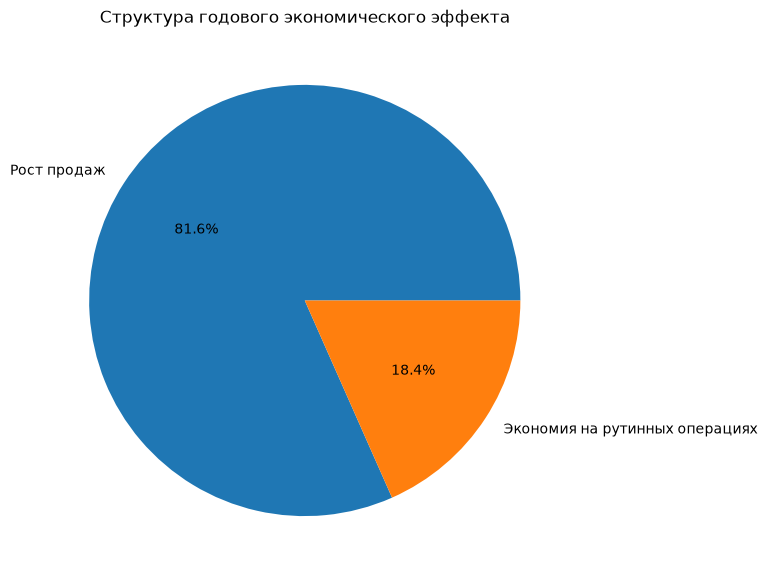

In [16]:
# Импортируем библиотеку для построения графиков
import matplotlib.pyplot as plt

# Данные для графика
effect_labels = [
    "Рост продаж",
    "Экономия на рутинных операциях"
]

effect_values = [
    additional_revenue,
    salary_saving
]

# Строим круговую диаграмму
plt.figure(figsize=(7, 7))

plt.pie(
    effect_values,
    labels=effect_labels,
    autopct="%1.1f%%"
)

# Заголовок графика
plt.title("Структура годового экономического эффекта")

# Показываем график
plt.show()